LEVEL 1: BASIC DATA REVIEW

Task 1.1: Overview of dataset-Total records &attributes

In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Dataset1.csv")
df.head(5)

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186074 entries, 0 to 186073
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   SN              186074 non-null  int64 
 1   Train_No        186074 non-null  int64 
 2   Station_Code    186074 non-null  object
 3   1A              186074 non-null  int64 
 4   2A              186074 non-null  int64 
 5   3A              186074 non-null  int64 
 6   SL              186074 non-null  int64 
 7   Station_Name    186074 non-null  object
 8   Route_Number    186074 non-null  int64 
 9   Arrival_time    186074 non-null  object
 10  Departure_Time  186074 non-null  object
 11  Distance        186074 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 17.0+ MB


In [ ]:
(df.shape)

(186074, 12)

In [ ]:
(df.columns)

Index(['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL',
       'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time',
       'Distance'],
      dtype='object')

Task 1.2: List all the train with their starting and ending stations

In [ ]:
df=df.sort_values(by=["Train_No","SN"])
start_station=df.groupby("Train_No").first()["Station_Name"]
end_station=df.groupby("Train_No").last()["Station_Name"]
train_routes=pd.DataFrame({'Starting Station': start_station,
                           'Ending Station':end_station
                           })
train_routes.reset_index(inplace=True)
print(train_routes)

       Train_No Starting Station Ending Station
0           107     SAWANTWADI R    MADGOAN JN.
1           108      MADGOAN JN.   SAWANTWADI R
2           128      MADGOAN JN.    CHHATRAPATI
3           290     DELHI-SAFDAR   DELHI-SAFDAR
4           401       AURANGABAD   VARANASI JN.
...         ...              ...            ...
11108     99904         PUNE JN.       TALEGAON
11109     99905         TALEGAON   SHIVAJINAGAR
11110     99906         PUNE JN.       TALEGAON
11111     99907         TALEGAON       PUNE JN.
11112     99908         PUNE JN.       TALEGAON

[11113 rows x 3 columns]


Task 1.3: Calculate no of stops per train

In [ ]:
stops_per_train=df.groupby('Train_No')['Station_Name'].count()
stops_per_train=stops_per_train.reset_index()
stops_per_train.columns=['Train_No','Number of stops']
print(stops_per_train)

       Train_No  Number of stops
0           107                4
1           108                4
2           128               22
3           290               14
4           401               12
...         ...              ...
11108     99904               12
11109     99905               11
11110     99906               12
11111     99907               12
11112     99908               12

[11113 rows x 2 columns]


Task 1.4 Trains with maximum and minimum number of stops

In [ ]:
max_stops=stops_per_train.loc[stops_per_train['Number of stops'].idxmax()]
min_stops=stops_per_train.loc[stops_per_train['Number of stops'].idxmin()]
print("Train with maximum stops")
print("Train_No:",max_stops['Train_No'])
print("Number of stops:",max_stops['Number of stops'])
print("Train with minimum stops")
print("Train_No:",min_stops['Train_No'])
print("Number of stops:",min_stops['Number of stops'])

Train with maximum stops
Train_No: 53041
Number of stops: 118
Train with minimum stops
Train_No: 557
Number of stops: 2


LEVEL 2:SIMPLE DATA PROCESSING

Task 2.1: Standardise schedule fields (arrival & departure time)

In [ ]:
df['Arrival_time']=pd.to_datetime(df['Arrival_time'],errors='coerce')
df['Departure_Time']=pd.to_datetime(df['Departure_Time'],errors='coerce')
print(df[['Arrival_time','Departure_Time']].dtypes)

Arrival_time      datetime64[ns]
Departure_Time    datetime64[ns]
dtype: object


/tmp/ipykernel_5102/339670000.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_time']=pd.to_datetime(df['Arrival_time'],errors='coerce')
/tmp/ipykernel_5102/339670000.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Departure_Time']=pd.to_datetime(df['Departure_Time'],errors='coerce')


Task 2.2:Compute total journey duration for each train

In [ ]:
df = df.sort_values(by=['Train_No', 'SN'])
start_time = df.groupby('Train_No').first()['Arrival_time']
end_time = df.groupby('Train_No').last()['Departure_Time']
journey_duration = end_time - start_time
journey_df = pd.DataFrame({
    'Start Time': start_time,
    'End Time': end_time,
    'Journey Duration': journey_duration
})
journey_df.reset_index(inplace=True)
print(journey_df.head())

   Train_No          Start Time            End Time  Journey Duration
0       107 2026-06-03 00:00:00 2026-06-03 00:00:00   0 days 00:00:00
1       108 2026-06-03 00:00:00 2026-06-03 00:00:00   0 days 00:00:00
2       128 2026-06-03 19:40:00 2026-06-03 17:45:00 -1 days +22:05:00
3       290 2026-06-03 18:30:00 2026-06-03 02:30:00 -1 days +08:00:00
4       401 2026-06-03 21:30:00 2026-06-03 10:00:00 -1 days +12:30:00


Task 2.3: Classify routes as short,medium or long

In [ ]:
route_distance=df.groupby('Train_No')['Distance'].max().reset_index()
def classify_route(distance):
  if distance<200:
    return"short"
  elif distance<500:
    return "medium"
  else:
    return"Long"
route_distance['Route Type']=route_distance['Distance'].apply(classify_route)

print(route_distance.head())


   Train_No  Distance Route Type
0       107        78      short
1       108        83      short
2       128       978       Long
3       290      2694       Long
4       401      1618       Long


Task 2.4:Generate station-wise train frequency counts

In [ ]:
station_frequency=df['Station_Name'].value_counts().reset_index()
station_frequency.columns=['Station_Name','Train Frequency']
print(station_frequency.head())

   Station_Name  Train Frequency
0    CST-MUMBAI             1027
1     KALYAN JN              828
2         THANE              796
3       SEALDAH              745
4  CHENNAI BEAC              738


Level 3: Data quality check

Task 3.1:Handle missing schedule values

In [ ]:
print(df.isnull().sum())

SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64


Task 3.2: Remove duplicate train records

In [ ]:
print("Duplicate Rows:",df.duplicated().sum)

Duplicate Rows: <bound method Series.sum of 0         False
1         False
2         False
3         False
4         False
          ...  
186064    False
186065    False
186066    False
186067    False
186068    False
Length: 186074, dtype: bool>


Task 3.3: Verify correct station order in each route

In [ ]:
df_sorted=df.sort_values(by=['Train_No','SN'])
print(df_sorted[['Train_No','SN','Station_Name']].head(20))

    Train_No  SN  Station_Name
0        107   1  SAWANTWADI R
1        107   2        THIVIM
2        107   3       KARMALI
3        107   4   MADGOAN JN.
4        108   1   MADGOAN JN.
5        108   2       KARMALI
6        108   3        THIVIM
7        108   4  SAWANTWADI R
8        128   1   MADGOAN JN.
9        128   2       KARMALI
10       128   3        THIVIM
11       128   4  SAWANTWADI R
12       128   5         KUDAL
13       128   6   SINDHU DURG
14       128   7     KANKAVALI
15       128   8   VAIBHAVWADI
16       128   9  RAJAPUR ROAD
17       128  10     RATNAGIRI
18       128  11   SANGMESHWAR
19       128  12       CHIPLUN


Task 3.4: Save the verified dataset

In [ ]:
df.to_csv('verified_train_dataset.csv',index=False)
print("verified dataset saved successfully")

verified dataset saved successfully


In [ ]:
from google.colab import files
files.download('verified_train_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Level 4:Basic Analysis and Visualization

Task 4.1:Compare average journey durations across route types

In [ ]:
journey_df=journey_df.merge(route_distance[['Train_No','Route Type']],
                            on='Train_No'
)
avg_duration=journey_df.groupby('Route Type')['Journey Duration'].mean()
print(avg_duration)

Route Type
Long     -1 days +20:57:34.608065247
medium     0 days 02:03:15.211267605
short      0 days 01:07:00.086523335
Name: Journey Duration, dtype: timedelta64[ns]


Task 4.2: Identify high-traffic stations

In [ ]:
high_traffic=station_frequency.head(10)
print(high_traffic)

   Station_Name  Train Frequency
0    CST-MUMBAI             1027
1     KALYAN JN              828
2         THANE              796
3       SEALDAH              745
4  CHENNAI BEAC              738
5    HOWRAH JN.              699
6         DADAR              598
7   DUM DUM JN.              463
8         KURLA              462
9      TAMBARAM              434


Task 4.3:Create basic visualizations for journey duration and station traffic

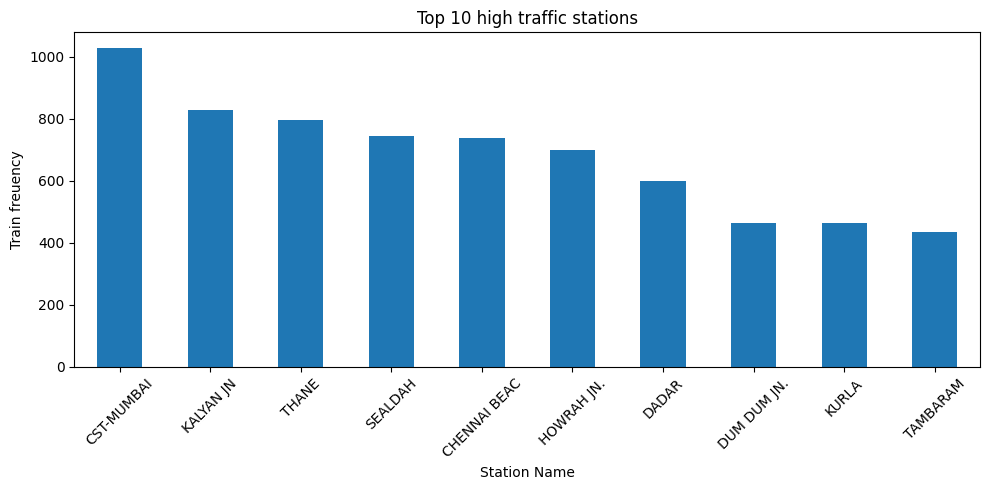

In [ ]:
import matplotlib.pyplot as plt
top_stations=df['Station_Name'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_stations.plot(kind='bar')
plt.title('Top 10 high traffic stations')
plt.xlabel('Station Name')
plt.ylabel('Train freuency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Task 4.4 - Key Observations

1. No missing values were found in the dataset.
2. No duplicate records were present.
3. Certain stations showed higher train frequency.
4. Longer routes generally had longer journey durations.

Conclusion:
The train schedule dataset was successfully analyzed...
